# 08 — Hata, hybrides et comparaison inter-familles, sans fuite

Suite du notebook 07. Même dataset (`radio_features_clean_ref.csv`, 327 mesures), même split Dev/Test, et l'ordre de Borda ainsi que les N\* viennent de la sélection faite **dans Dev** au notebook 07.

## Ce qui change par rapport aux notebooks 03, 04 et 06

| Étape | Notebooks 03 / 04 / 06 | Ici |
|---|---|---|
| Calibration Hata L1a / L1b / L2 | estimée sur `train_filtered` — *déjà propre* | estimée sur `dev_filtered` — **inchangé** |
| Ordre de Borda pour l'ablation hybride | dérivé du test | repris du notebook 07 (out-of-fold Dev) |
| Ablation A1 / A2, choix de N\* | `argmin` RMSE **test** | validation croisée **dans Dev**, règle du plateau à 1 erreur type |
| Ê_L2 utilisé pendant l'ablation | ajusté une fois sur tout le train | **réajusté dans chaque pli** — sinon les points de validation informent leur propre Ê_L2 |
| Test | instrument de sélection **et** de mesure | **mesure finale, une seule fois** |

La calibration Hata et le calcul ITU-R sont repris tels quels : ils étaient déjà estimés sur le train seul.

## Contrainte physique conservée
Hata et P.1546-6 ne sont pas définis pour d < 1 km. Le filtre `Distance ≥ 1000 m` est appliqué **indépendamment** à Dev et au Test, comme dans le notebook 03.


---
## §0 — Configuration, et reprise des décisions du notebook 07

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

from sklearn.model_selection import train_test_split, RepeatedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

BASE = Path('.').resolve()
NB07 = BASE / 'outputs_nb07'
OUT  = BASE / 'outputs_nb08'
OUT.mkdir(exist_ok=True)

SEED   = 42
TARGET = 'E_field'
np.random.seed(SEED)

ABL_SPLITS, ABL_REPEATS = 5, 2      # CV dans Dev pour l'ablation hybride
ML_NAMES = ['RF', 'XGBoost', 'CatBoost', 'LightGBM']

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
ENV_COLORS = {'urban': '#1565C0', 'suburban': '#2E7D32'}

def evaluate(y_true, y_pred):
    return {'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'MAE':  float(mean_absolute_error(y_true, y_pred)),
            'R2':   float(r2_score(y_true, y_pred)),
            'Bias': float(np.mean(y_pred - y_true))}

# ── Décisions reprises du notebook 07 ──────────────────────────────────────
with open(NB07 / 'best_params_dev.json') as f:
    BEST = json.load(f)

imp_multi = pd.read_csv(NB07 / 'feature_importance_multi_dev.csv', index_col=0)
TIE_BREAK_ORDER = ['First_building_m', 'Fresnel_trees']
BORDA_ORDER = []
for rank in sorted(imp_multi['Borda_rank'].unique()):
    g = imp_multi[imp_multi['Borda_rank'] == rank].index.tolist()
    if len(g) > 1:
        g = [f for f in TIE_BREAK_ORDER if f in g] + [f for f in g if f not in TIE_BREAK_ORDER]
    BORDA_ORDER.extend(g)

nstar_df = pd.read_csv(NB07 / 'nstar_selection_dev.csv')
NSTAR_PUREML = dict(zip(nstar_df['Model'], nstar_df['N*']))

def build_ml(name):
    p = BEST[name].copy()
    if name == 'RF':       return RandomForestRegressor(random_state=SEED, n_jobs=-1, **p)
    if name == 'XGBoost':  return XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0, **p)
    if name == 'CatBoost': return CatBoostRegressor(random_seed=SEED, verbose=0, thread_count=-1, **p)
    if name == 'LightGBM': return lgb.LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1, **p)

print('Décisions reprises du notebook 07 :')
print('  Ordre de Borda (5 premiers) :', BORDA_ORDER[:5])
print('  N* Pure ML :', NSTAR_PUREML)

Décisions reprises du notebook 07 :
  Ordre de Borda (5 premiers) : ['Roughness_Tx_Rx_50m', 'Slope_Tx_Rx_50m', 'Azimut_Tx_Rx', 'Rx_height', 'Rhum']
  N* Pure ML : {'RF': 4, 'XGBoost': 5, 'CatBoost': 4, 'LightGBM': 5}


---
## §1 — Données et split Dev / Test (identiques au notebook 07)

In [2]:
df = pd.read_csv(BASE / 'radio_features_clean_ref.csv')
df['zone']       = df['Ref'].apply(lambda r: int(r.rsplit('_', 1)[1][0]))
df['city']       = df['Ref'].apply(lambda r: r.rsplit('_', 1)[0].capitalize())
df['zone_label'] = df['city'] + '_Z' + df['zone'].astype(int).astype(str)

FEAT_GROUPS = {
    'System':    ['Tx_power', 'Tx_height', 'Freq'],
    'Distance':  ['Distance'],
    'Terrain':   ['Slope_Tx_Rx_50m', 'Roughness_Tx_Rx_50m', 'Rx_height'],
    'Geometry':  ['Azimut_Tx_Rx', 'Tilt_Tx_Rx'],
    'Obstacles': ['LOS', 'First_building_m', 'First_tree_m',
                  'Fresnel_buildings', 'Fresnel_trees',
                  'Buildings_near_Rx', 'Trees_near_Rx'],
    'Weather':     ['Temp', 'Rhum'],
    'Context':   ['Environment'],
}
ALL_FEATURES = [f for feats in FEAT_GROUPS.values() for f in feats]

dev_df, test_df = train_test_split(df, test_size=0.20, random_state=SEED,
                                   stratify=df['Environment'])
dev_df, test_df = dev_df.reset_index(drop=True), test_df.reset_index(drop=True)

# ── Filtre physique d ≥ 1 km, appliqué séparément à Dev et au Test ─────────
dev_f  = dev_df[dev_df['Distance']  >= 1000.0].copy().reset_index(drop=True)
test_f = test_df[test_df['Distance'] >= 1000.0].copy().reset_index(drop=True)

y_dev_f, y_test_f = dev_f[TARGET].values, test_f[TARGET].values
env_dev_f, env_test_f = dev_f['Environment'].values, test_f['Environment'].values

print(f'Dev  : {len(dev_df)} pts → d≥1 km : {len(dev_f)} pts  (exclus {len(dev_df)-len(dev_f)})')
print(f'Test : {len(test_df)} pts → d≥1 km : {len(test_f)} pts  (exclus {len(test_df)-len(test_f)})')
print(f'  test filtré — urbain {int((env_test_f==1).sum())} | suburbain {int((env_test_f==0).sum())}')
print()
print('*** Le test reste scellé jusqu au §6. ***')

Dev  : 261 pts → d≥1 km : 242 pts  (exclus 19)
Test : 66 pts → d≥1 km : 62 pts  (exclus 4)
  test filtré — urbain 39 | suburbain 23

*** Le test reste scellé jusqu au §6. ***


---
## §2 — Hata standard (référence non calibrée)

Formule et implémentation reprises telles quelles du notebook 03.

In [3]:
def okumura_hata_efield(f_mhz, d_m, h_b, h_m, erp_w, is_urban):
    d_km = d_m / 1000.0
    if d_km < 1.0:
        return np.nan
    a_hm    = 3.2 * (np.log10(11.75 * h_m)) ** 2 - 4.97
    L_urban = (69.55 + 26.16 * np.log10(f_mhz) - 13.82 * np.log10(h_b)
               - a_hm + (44.9 - 6.55 * np.log10(h_b)) * np.log10(d_km))
    L = L_urban if is_urban else L_urban - 2 * (np.log10(f_mhz / 28)) ** 2 - 5.4
    L = max(L, 32.45 + 20 * np.log10(d_km) + 20 * np.log10(f_mhz))
    return 10 * np.log10(erp_w) + 32.15 - L + 20 * np.log10(f_mhz) + 77.2

def apply_hata(d):
    return d.apply(lambda r: okumura_hata_efield(
        r['Freq'], r['Distance'], r['Tx_antenna_height'], r['Rx_antenna_height'],
        r['Tx_power'], bool(r['Environment'])), axis=1).values

hata_dev  = apply_hata(dev_f)
hata_test = apply_hata(test_f)
assert not np.isnan(hata_dev).any() and not np.isnan(hata_test).any()

res_dev = y_dev_f - hata_dev
print(f'Résidus Hata standard sur Dev filtré (n={len(dev_f)}) :')
print(f'  biais = {res_dev.mean():+.3f} dB   std = {res_dev.std():.3f} dB')
for e, lbl in [(1, 'urbain   '), (0, 'suburbain')]:
    m = env_dev_f == e
    print(f'  {lbl} (n={int(m.sum()):3d}) : biais={res_dev[m].mean():+.3f} dB  std={res_dev[m].std():.3f} dB')

Résidus Hata standard sur Dev filtré (n=242) :
  biais = -13.379 dB   std = 11.212 dB
  urbain    (n=149) : biais=-18.600 dB  std=11.179 dB
  suburbain (n= 93) : biais=-5.014 dB  std=3.638 dB


---
## §3 — Calibration progressive (L1a, L1b, L2)

Tous les paramètres sont estimés sur **Dev filtré uniquement**. C'était déjà le cas dans le notebook 03 : seul le nom de la partition change.

In [4]:
# ── L1a : offset global ─────────────────────────────────────────────────────
delta_global = float(res_dev.mean())

# ── L1b : offset par environnement ──────────────────────────────────────────
deltas_env = {e: float(res_dev[env_dev_f == e].mean()) for e in (0, 1)}

print(f'Δ_global   = {delta_global:+.4f} dB')
print(f'Δ_urbain   = {deltas_env[1]:+.4f} dB  (n={int((env_dev_f==1).sum())})')
print(f'Δ_suburbain= {deltas_env[0]:+.4f} dB  (n={int((env_dev_f==0).sum())})')

Δ_global   = -13.3790 dB
Δ_urbain   = -18.6004 dB  (n=149)
Δ_suburbain= -5.0135 dB  (n=93)


In [5]:
# ── L2 : ré-estimation OLS des coefficients log-linéaires de Hata ──────────
def build_ols_df(d):
    d_km = d['Distance'].values / 1000.0
    h_b  = d['Tx_antenna_height'].values
    h_m  = d['Rx_antenna_height'].values
    a_hm = 3.2 * (np.log10(11.75 * h_m)) ** 2 - 4.97
    return pd.DataFrame({
        'log_d':        np.log10(d_km),
        'log_f':        np.log10(d['Freq'].values),
        'log_hb':       np.log10(h_b),
        'a_hm':         a_hm,
        'log_hb_log_d': np.log10(h_b) * np.log10(d_km),
        'log_erp':      np.log10(d['Tx_power'].values),
        'Environment':  d['Environment'].values.astype(float),
    })

X_ols_dev  = sm.add_constant(build_ols_df(dev_f))
X_ols_test = sm.add_constant(build_ols_df(test_f))
ols_l2 = sm.OLS(y_dev_f, X_ols_dev).fit()

e_l2_dev  = ols_l2.predict(X_ols_dev).values
e_l2_test = ols_l2.predict(X_ols_test).values
delta_l2_dev = y_dev_f - e_l2_dev

print(ols_l2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     79.25
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           1.38e-42
Time:                        11:57:00   Log-Likelihood:                -806.23
No. Observations:                 242   AIC:                             1622.
Df Residuals:                     237   BIC:                             1640.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
log_d         -311.0472    567.729     -0.548   

In [6]:
# ── Diagnostic d'identifiabilité de la régression L2 ────────────────────────
# La matrice de design est-elle de rang plein ? Avec deux villes seulement,
# plusieurs covariables « physiques » sont constantes ou déterminées par la ville.

Xv = X_ols_dev.values
rank, ncol = int(np.linalg.matrix_rank(Xv)), Xv.shape[1]
print(f'Colonnes (constante incluse) : {ncol}   |   rang effectif : {rank}')
print(f'Conditionnement : {np.linalg.cond(Xv):.2e}')
print()
print('Nombre de valeurs distinctes par covariable :')
for c in X_ols_dev.columns:
    nu = X_ols_dev[c].nunique()
    flag = '  ← constante' if nu == 1 else ('  ← binaire (déterminée par la ville)' if nu == 2 else '')
    print(f'  {c:14s} {nu:4d}{flag}')
print()
print(f'→ {ncol - rank} degrés de liberté manquants : {ncol - rank} coefficients ne sont pas identifiables.')
print('  Les prédictions Ê_L2 restent valides et reproductibles, mais les VALEURS')
print('  des coefficients (et leurs signes) ne sont pas interprétables : elles')
print('  désignent un point arbitraire dans le noyau de la matrice de design.')
print('  À ne pas commenter comme des « exposants de propagation ré-estimés ».')

Colonnes (constante incluse) : 7   |   rang effectif : 5
Conditionnement : 6.91e+16

Nombre de valeurs distinctes par covariable :
  log_d           242
  log_f             2  ← binaire (déterminée par la ville)
  log_hb            2  ← binaire (déterminée par la ville)
  a_hm              1  ← constante
  log_hb_log_d    242
  log_erp           2  ← binaire (déterminée par la ville)
  Environment       2  ← binaire (déterminée par la ville)

→ 2 degrés de liberté manquants : 2 coefficients ne sont pas identifiables.
  Les prédictions Ê_L2 restent valides et reproductibles, mais les VALEURS
  des coefficients (et leurs signes) ne sont pas interprétables : elles
  désignent un point arbitraire dans le noyau de la matrice de design.
  À ne pas commenter comme des « exposants de propagation ré-estimés ».


---
## §4 — ITU-R P.1546-6 (aucun paramètre estimé)

Repris tel quel du notebook 03, corrections tropicale et hauteur de récepteur comprises.

In [7]:
D_KM     = np.array([1., 2., 3., 4., 5., 6., 7., 8., 9., 10.])
H1_TABLE = np.array([75., 150., 300.])
TABLE_100 = np.array([
    [75.0, 69.5, 65.5, 62.5, 59.5, 57.0, 54.5, 52.5, 51.0, 49.0],
    [80.0, 74.5, 70.5, 67.5, 64.5, 62.0, 59.5, 57.5, 56.0, 54.0],
    [85.5, 80.0, 76.0, 73.0, 70.0, 67.5, 65.0, 63.0, 61.5, 59.5]])
TABLE_600 = np.array([
    [71.0, 63.5, 58.5, 54.5, 51.0, 48.0, 45.5, 43.5, 41.5, 40.0],
    [77.0, 69.5, 64.5, 60.5, 57.0, 54.0, 51.5, 49.5, 47.5, 46.0],
    [83.0, 75.5, 70.5, 66.5, 63.0, 60.0, 57.5, 55.5, 53.5, 52.0]])
C_TROP_P1546 = (100.0 - 43.3) / 20.0

def _interp_h1_dist(table, h1_m, d_km):
    h1_c, d_c = np.clip(h1_m, H1_TABLE[0], H1_TABLE[-1]), np.clip(d_km, D_KM[0], D_KM[-1])
    e = np.array([np.interp(np.log10(d_c), np.log10(D_KM), table[i, :]) for i in range(3)])
    return np.interp(np.log10(h1_c), np.log10(H1_TABLE), e)

def _interp_freq(e100, e600, f):
    return e100 + (e600 - e100) * (np.log10(f) - np.log10(100.)) / (np.log10(600.) - np.log10(100.))

def _p1546_h2_correction(f_mhz, d_km, h1_m, h2_m, is_urban):
    R2 = 15.0 if is_urban else 10.0
    R2p = max(1.0, (1000.0*d_km*R2 - 15.0*h1_m) / (1000.0*d_km - 15.0)) if is_urban else R2
    R2p = np.clip(R2p, 1.0, R2)
    K_h2 = 3.2 + 6.2 * np.log10(f_mhz)
    if h2_m < R2p:
        nu = 0.0108*np.sqrt(f_mhz) * np.sqrt((R2p-h2_m) * np.degrees(np.arctan((R2p-h2_m)/27.0)))
        J = (6.9 + 20.0*np.log10(np.sqrt((nu-0.1)**2+1.0)+nu-0.1)) if nu > -0.7806 else 0.0
        c = 6.03 - J
    else:
        c = K_h2 * np.log10(h2_m / R2p)
    if is_urban and R2p < 10.0:
        c -= K_h2 * np.log10(10.0 / R2p)
    return c

def itu_p1546(row):
    d_km, f = row['Distance']/1000.0, row['Freq']
    h1, h2  = row['Tx_antenna_height'], row['Rx_antenna_height']
    e_ref = _interp_freq(_interp_h1_dist(TABLE_100, h1, d_km),
                         _interp_h1_dist(TABLE_600, h1, d_km), f)
    return (e_ref + 10.0*np.log10(row['Tx_power']/1000.0)
            + (C_TROP_P1546 * np.log10(d_km) if d_km >= 1.0 else 0.0)
            + _p1546_h2_correction(f, d_km, h1, h2, bool(row['Environment'])))

itu_test = test_f.apply(itu_p1546, axis=1).values
print(f'ITU-R P.1546-6 calculé sur le test filtré (n={len(test_f)}) — aucun paramètre estimé.')

ITU-R P.1546-6 calculé sur le test filtré (n=62) — aucun paramètre estimé.


---
## §5 — Hybrides A1 / A2 : ablation et choix de N\* **dans Dev**

C'est ici que se trouve la correction. Dans le notebook 04, l'ablation N=1..22 était évaluée sur le test et N\* pris à l'`argmin`. Ici elle est évaluée en validation croisée répétée dans Dev filtré.

Deux précautions :
- **Ê_L2 est réajusté dans chaque pli** (OLS sur le pli d'entraînement seul). Sinon les points de validation auraient contribué à leur propre prédiction Hata calibrée.
- N\* est choisi par la **règle du plateau à 1 erreur type**, pas par l'`argmin`.

- **A1** : les N premières features de Borda + Ê_L2 comme feature supplémentaire → E_field
- **A2** : les N premières features → δ = E_field − Ê_L2, puis prédiction finale = Ê_L2 + δ̂

In [8]:
rkf = RepeatedKFold(n_splits=ABL_SPLITS, n_repeats=ABL_REPEATS, random_state=SEED)
folds = list(rkf.split(dev_f))
n_est = len(folds)
print(f'Ablation hybride + Pure ML — {n_est} estimations par point, dans Dev filtré (n={len(dev_f)})')

rows_a0, rows_a1, rows_a2 = [], [], []
for n in range(1, 20):
    feats = BORDA_ORDER[:n]
    r0 = {'N': n}; r1 = {'N': n}; r2_ = {'N': n}
    acc0 = {m: [] for m in ML_NAMES}; acc1 = {m: [] for m in ML_NAMES}; acc2 = {m: [] for m in ML_NAMES}
    for tr, va in folds:
        d_tr, d_va = dev_f.iloc[tr], dev_f.iloc[va]
        # Ê_L2 réajusté sur le pli d'entraînement uniquement
        ols_k = sm.OLS(d_tr[TARGET].values, sm.add_constant(build_ols_df(d_tr))).fit()
        e_tr  = ols_k.predict(sm.add_constant(build_ols_df(d_tr))).values
        e_va  = ols_k.predict(sm.add_constant(build_ols_df(d_va))).values
        ytr, yva = d_tr[TARGET].values, d_va[TARGET].values

        Xtr0, Xva0 = d_tr[feats].values, d_va[feats].values   # Pure ML — même features, pas de Ê_L2
        Xtr1 = np.column_stack([d_tr[feats].values, e_tr])
        Xva1 = np.column_stack([d_va[feats].values, e_va])
        Xtr2, Xva2 = d_tr[feats].values, d_va[feats].values
        for mdl in ML_NAMES:
            m0 = build_ml(mdl); m0.fit(Xtr0, ytr)
            acc0[mdl].append(float(np.sqrt(mean_squared_error(yva, m0.predict(Xva0)))))
            m1 = build_ml(mdl); m1.fit(Xtr1, ytr)
            acc1[mdl].append(float(np.sqrt(mean_squared_error(yva, m1.predict(Xva1)))))
            m2 = build_ml(mdl); m2.fit(Xtr2, ytr - e_tr)
            acc2[mdl].append(float(np.sqrt(mean_squared_error(yva, e_va + m2.predict(Xva2)))))
    for mdl in ML_NAMES:
        r0[f'{mdl}_RMSE']   = round(float(np.mean(acc0[mdl])), 4)
        r0[f'{mdl}_RMSEsd'] = round(float(np.std(acc0[mdl], ddof=1)), 4)
        r1[f'{mdl}_RMSE']   = round(float(np.mean(acc1[mdl])), 4)
        r1[f'{mdl}_RMSEsd'] = round(float(np.std(acc1[mdl], ddof=1)), 4)
        r2_[f'{mdl}_RMSE']   = round(float(np.mean(acc2[mdl])), 4)
        r2_[f'{mdl}_RMSEsd'] = round(float(np.std(acc2[mdl], ddof=1)), 4)
    rows_a0.append(r0); rows_a1.append(r1); rows_a2.append(r2_)
    print(f'  N={n:2d}  ML ' + ' '.join(f'{m}:{r0[f"{m}_RMSE"]:.3f}' for m in ML_NAMES) +
          '   |  A1 ' + ' '.join(f'{m}:{r1[f"{m}_RMSE"]:.3f}' for m in ML_NAMES) +
          '   |  A2 ' + ' '.join(f'{m}:{r2_[f"{m}_RMSE"]:.3f}' for m in ML_NAMES))

pureml_abl = pd.DataFrame(rows_a0)
a1_abl = pd.DataFrame(rows_a1); a2_abl = pd.DataFrame(rows_a2)
pureml_abl.to_csv(OUT / 'pureml_ablation_dev_filtered.csv', index=False)
a1_abl.to_csv(OUT / 'hybrid_A1_ablation_dev.csv', index=False)
a2_abl.to_csv(OUT / 'hybrid_A2_ablation_dev.csv', index=False)
print('\nSauvé → outputs_nb08/pureml_ablation_dev_filtered.csv, hybrid_A{1,2}_ablation_dev.csv')

Ablation hybride + Pure ML — 10 estimations par point, dans Dev filtré (n=242)


  N= 1  ML RF:7.435 XGBoost:7.285 CatBoost:7.238 LightGBM:7.058   |  A1 RF:6.530 XGBoost:6.685 CatBoost:6.682 LightGBM:6.922   |  A2 RF:7.194 XGBoost:7.150 CatBoost:6.996 LightGBM:6.891


  N= 2  ML RF:6.500 XGBoost:6.888 CatBoost:6.751 LightGBM:6.835   |  A1 RF:6.341 XGBoost:6.587 CatBoost:6.372 LightGBM:6.755   |  A2 RF:6.368 XGBoost:6.752 CatBoost:6.507 LightGBM:6.577


  N= 3  ML RF:5.562 XGBoost:6.372 CatBoost:5.727 LightGBM:5.873   |  A1 RF:5.548 XGBoost:5.947 CatBoost:5.584 LightGBM:5.919   |  A2 RF:5.623 XGBoost:6.333 CatBoost:5.687 LightGBM:5.894


  N= 4  ML RF:5.600 XGBoost:5.849 CatBoost:5.722 LightGBM:5.718   |  A1 RF:5.557 XGBoost:5.748 CatBoost:5.675 LightGBM:5.827   |  A2 RF:5.640 XGBoost:5.929 CatBoost:5.745 LightGBM:5.857


...

  N=15  ML RF:5.578 XGBoost:5.608 CatBoost:5.550 LightGBM:5.478   |  A1 RF:5.564 XGBoost:5.635 CatBoost:5.579 LightGBM:5.487   |  A2 RF:5.629 XGBoost:5.590 CatBoost:5.507 LightGBM:5.609


  N=16  ML RF:5.599 XGBoost:5.584 CatBoost:5.547 LightGBM:5.491   |  A1 RF:5.592 XGBoost:5.686 CatBoost:5.518 LightGBM:5.489   |  A2 RF:5.637 XGBoost:5.560 CatBoost:5.527 LightGBM:5.568


  N=17  ML RF:5.593 XGBoost:5.666 CatBoost:5.534 LightGBM:5.491   |  A1 RF:5.576 XGBoost:5.673 CatBoost:5.531 LightGBM:5.489   |  A2 RF:5.640 XGBoost:5.585 CatBoost:5.554 LightGBM:5.568


  N=18  ML RF:5.598 XGBoost:5.658 CatBoost:5.551 LightGBM:5.478   |  A1 RF:5.597 XGBoost:5.695 CatBoost:5.496 LightGBM:5.508   |  A2 RF:5.675 XGBoost:5.635 CatBoost:5.550 LightGBM:5.605


  N=19  ML RF:5.602 XGBoost:5.683 CatBoost:5.548 LightGBM:5.478   |  A1 RF:5.596 XGBoost:5.684 CatBoost:5.524 LightGBM:5.508   |  A2 RF:5.632 XGBoost:5.636 CatBoost:5.567 LightGBM:5.605

Sauvé → outputs_nb08/pureml_ablation_dev_filtered.csv, hybrid_A{1,2}_ablation_dev.csv


In [9]:
# ── N* par la règle du plateau à 1 erreur type ───────────────────────────────
def pick_nstar(abl, mdl):
    mu = abl[f'{mdl}_RMSE'].values
    sd = abl[f'{mdl}_RMSEsd'].values
    j  = int(np.argmin(mu))
    thr = mu[j] + sd[j] / np.sqrt(n_est)
    return int(abl['N'].values[np.argmax(mu <= thr)]), float(mu[j]), float(thr)

NSTAR_A1, NSTAR_A2, NSTAR_PUREML_FILTERED, rows = {}, {}, {}, []
for mdl in ML_NAMES:
    n0, b0, t0 = pick_nstar(pureml_abl, mdl)
    n1, b1, t1 = pick_nstar(a1_abl, mdl)
    n2, b2, t2 = pick_nstar(a2_abl, mdl)
    NSTAR_PUREML_FILTERED[mdl] = n0
    NSTAR_A1[mdl], NSTAR_A2[mdl] = n1, n2
    rows.append({'Model': mdl,
                 'PureML_N*_filtered': n0, 'PureML_RMSE_dev': round(float(pureml_abl[f'{mdl}_RMSE'].values[n0-1]), 4),
                 'A1_N*': n1, 'A1_RMSE_dev': round(float(a1_abl[f'{mdl}_RMSE'].values[n1-1]), 4),
                 'A2_N*': n2, 'A2_RMSE_dev': round(float(a2_abl[f'{mdl}_RMSE'].values[n2-1]), 4),
                 'PureML_N*_full_dev': NSTAR_PUREML[mdl]})
nstar_hyb = pd.DataFrame(rows)
nstar_hyb.to_csv(OUT / 'nstar_hybrides_dev.csv', index=False)
print('=== N* retenus — Pure ML, A1 et A2 tous sélectionnés dans Dev filtré (plateau à 1 erreur type) ===')
print('(PureML_N*_full_dev = ancien N* choisi sur tout Dev, notebook 07, gardé ici pour Table 6 uniquement)')
print(nstar_hyb.to_string(index=False))

=== N* retenus — Pure ML, A1 et A2 tous sélectionnés dans Dev filtré (plateau à 1 erreur type) ===
(PureML_N*_full_dev = ancien N* choisi sur tout Dev, notebook 07, gardé ici pour Table 6 uniquement)
   Model  PureML_N*_filtered  PureML_RMSE_dev  A1_N*  A1_RMSE_dev  A2_N*  A2_RMSE_dev  PureML_N*_full_dev
      RF                   5           5.4711      3       5.5479      3       5.6233                   4
 XGBoost                   5           5.6717      4       5.7483      5       5.6979                   5
CatBoost                   5           5.5380      3       5.5843      5       5.5580                   4
LightGBM                   5           5.5486     13       5.4842      7       5.6798                   5


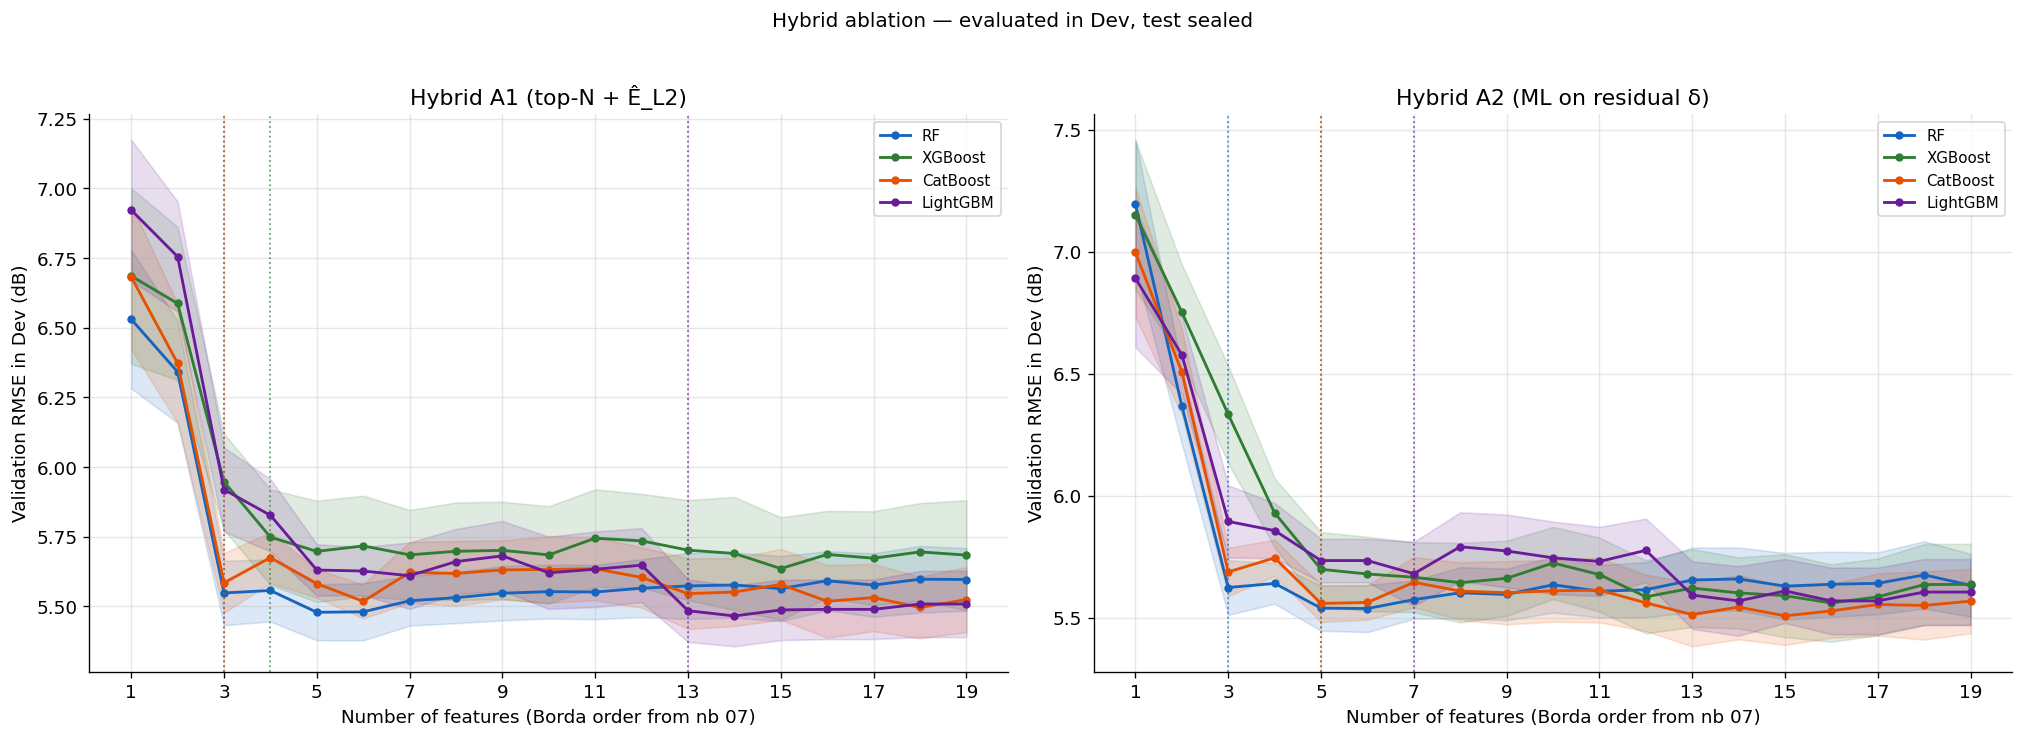

In [10]:
# ── Figure : courbes d'ablation hybrides (Dev) ───────────────────────────────
C = {'RF': '#1565C0', 'XGBoost': '#2E7D32', 'CatBoost': '#E65100', 'LightGBM': '#6A1B9A'}
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for ax, abl, ttl, ns in [(axes[0], a1_abl, 'Hybrid A1 (top-N + Ê_L2)', NSTAR_A1),
                         (axes[1], a2_abl, 'Hybrid A2 (ML on residual δ)', NSTAR_A2)]:
    for mdl, c in C.items():
        mu = abl[f'{mdl}_RMSE']; se = abl[f'{mdl}_RMSEsd'] / np.sqrt(n_est)
        ax.plot(abl['N'], mu, marker='o', color=c, lw=1.7, markersize=4, label=mdl)
        ax.fill_between(abl['N'], mu - se, mu + se, color=c, alpha=0.15)
        ax.axvline(ns[mdl], color=c, ls=':', lw=1.1, alpha=0.7)
    ax.set_xlabel('Number of features (Borda order from nb 07)')
    ax.set_ylabel('Validation RMSE in Dev (dB)')
    ax.set_title(ttl); ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_xticks(abl['N'][::2])
plt.suptitle('Hybrid ablation — evaluated in Dev, test sealed', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'fig_ablation_hybrides_dev.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig_ablation_hybrides_dev.png', dpi=150, bbox_inches='tight')
plt.show()

---
## §6 — Comparaison inter-familles sur le test scellé

Première et unique lecture du test. Toutes les familles sont évaluées sur le **même sous-ensemble** d ≥ 1 km, et chaque modèle ML utilise le N\* choisi dans Dev.

On ajoute le R² par environnement et les deux lignes de base triviales, pour la raison exposée au notebook 07 : sur un jeu bimodal, un R² global ne dit pas à lui seul que le modèle a appris la propagation.

In [11]:
def add_row(rows, family, name, n_str, pred):
    m = evaluate(y_test_f, pred)
    r = {'Famille': family, 'Modèle': name, 'N': n_str, **m}
    for e, lbl in [(1, 'Urbain'), (0, 'Suburbain')]:
        msk = env_test_f == e
        r[f'RMSE_{lbl}'] = round(float(np.sqrt(mean_squared_error(y_test_f[msk], pred[msk]))), 3)
        r[f'R2_{lbl}']   = round(float(r2_score(y_test_f[msk], pred[msk])), 3)
    rows.append(r)

rows = []
# ── Familles empiriques ────────────────────────────────────────────────────
add_row(rows, 'Uncalibrated empirical', 'ITU-R P.1546-6', '—', itu_test)
add_row(rows, 'Uncalibrated empirical', 'Hata standard',  '—', hata_test)
add_row(rows, 'Calibrated empirical', 'Hata L1a (global offset)', '1', hata_test + delta_global)
pred_1b = hata_test + np.array([deltas_env[e] for e in env_test_f])
add_row(rows, 'Calibrated empirical', 'Hata L1b (offset/env)', '2', pred_1b)
add_row(rows, 'Calibrated empirical', 'Hata L2 (OLS)', '7', e_l2_test)

# ── Pure ML : entraîné sur Dev filtré, évalué sur le test filtré ──────────
# (même domaine que Hata calibré et les hybrides, pour isoler proprement l'apport
# de l'hybridation — N* lui aussi sélectionné dans Dev filtré, cf. cellule §5)
pureml_preds = {}
for mdl in ML_NAMES:
    fe = BORDA_ORDER[:NSTAR_PUREML_FILTERED[mdl]]
    m = build_ml(mdl); m.fit(dev_f[fe].values, y_dev_f)
    p = m.predict(test_f[fe].values)
    pureml_preds[mdl] = p
    add_row(rows, 'Pure ML', mdl, str(NSTAR_PUREML_FILTERED[mdl]), p)

# ── Hybrides : entraînés sur Dev filtré ────────────────────────────────────
a1_preds, a2_preds = {}, {}
for mdl in ML_NAMES:
    f1 = BORDA_ORDER[:NSTAR_A1[mdl]]
    m1 = build_ml(mdl)
    m1.fit(np.column_stack([dev_f[f1].values, e_l2_dev]), y_dev_f)
    a1_preds[mdl] = m1.predict(np.column_stack([test_f[f1].values, e_l2_test]))
    add_row(rows, 'Hybrid A1', f'A1-{mdl}', str(NSTAR_A1[mdl]), a1_preds[mdl])

    f2 = BORDA_ORDER[:NSTAR_A2[mdl]]
    m2 = build_ml(mdl); m2.fit(dev_f[f2].values, delta_l2_dev)
    a2_preds[mdl] = e_l2_test + m2.predict(test_f[f2].values)
    add_row(rows, 'Hybrid A2', f'A2-{mdl}', str(NSTAR_A2[mdl]), a2_preds[mdl])

# ── Lignes de base triviales ───────────────────────────────────────────────
add_row(rows, 'Trivial baseline', 'Global mean (Dev)', '0',
        np.full_like(y_test_f, y_dev_f.mean()))
cm = {e: y_dev_f[env_dev_f == e].mean() for e in (0, 1)}
add_row(rows, 'Trivial baseline', 'Mean by city (Dev)', '0',
        np.array([cm[e] for e in env_test_f]))

full = pd.DataFrame(rows)
for c in ['RMSE', 'MAE', 'Bias']: full[c] = full[c].round(3)
full['R2'] = full['R2'].round(3)
full.to_csv(OUT / 'cross_family_final.csv', index=False)

print(f'=== COMPARAISON INTER-FAMILLES — test scellé, d≥1 km, n={len(test_f)} ===')
print(full.to_string(index=False))
print('\nSauvé → outputs_nb08/cross_family_final.csv')

=== COMPARAISON INTER-FAMILLES — test scellé, d≥1 km, n=62 ===
               Famille                   Modèle  N   RMSE    MAE     R2   Bias  RMSE_Urbain  R2_Urbain  RMSE_Suburbain  R2_Suburbain
Uncalibrated empirical           ITU-R P.1546-6  — 13.639 11.732 -0.877 -8.872       12.762     -1.352          15.008       -10.060
Uncalibrated empirical            Hata standard  — 17.810 13.755 -2.201 13.541       21.747     -5.830           7.285        -1.606
  Calibrated empirical Hata L1a (global offset)  1 11.569  9.730 -0.351  0.162       12.927     -1.413           8.801        -2.804
  Calibrated empirical    Hata L1b (offset/env)  2  9.932  7.803  0.005 -0.019       12.036     -1.092           4.503         0.005
  Calibrated empirical            Hata L2 (OLS)  7  6.998  5.368  0.506 -0.103        8.116      0.049           4.506         0.003
               Pure ML                       RF  5  4.776  4.018  0.770  0.417        5.313      0.592           3.689         0.332
      

=== SYNTHÈSE — meilleur représentant de chaque famille ===
               Famille             Modèle  N   RMSE    MAE     R2   Bias  R2_Urbain  R2_Suburbain
Uncalibrated empirical     ITU-R P.1546-6  — 13.639 11.732 -0.877 -8.872     -1.352       -10.060
  Calibrated empirical      Hata L2 (OLS)  7  6.998  5.368  0.506 -0.103      0.049         0.003
               Pure ML                 RF  5  4.776  4.018  0.770  0.417      0.592         0.332
             Hybrid A1        A1-LightGBM 13  4.952  4.142  0.753  0.106      0.574         0.210
             Hybrid A2        A2-CatBoost  5  4.738  3.993  0.773  0.481      0.595         0.364
      Trivial baseline  Global mean (Dev)  0  9.956  8.858 -0.000 -0.131     -0.389        -4.113
      Trivial baseline Mean by city (Dev)  0  7.190  5.740  0.478 -0.341     -0.011        -0.014


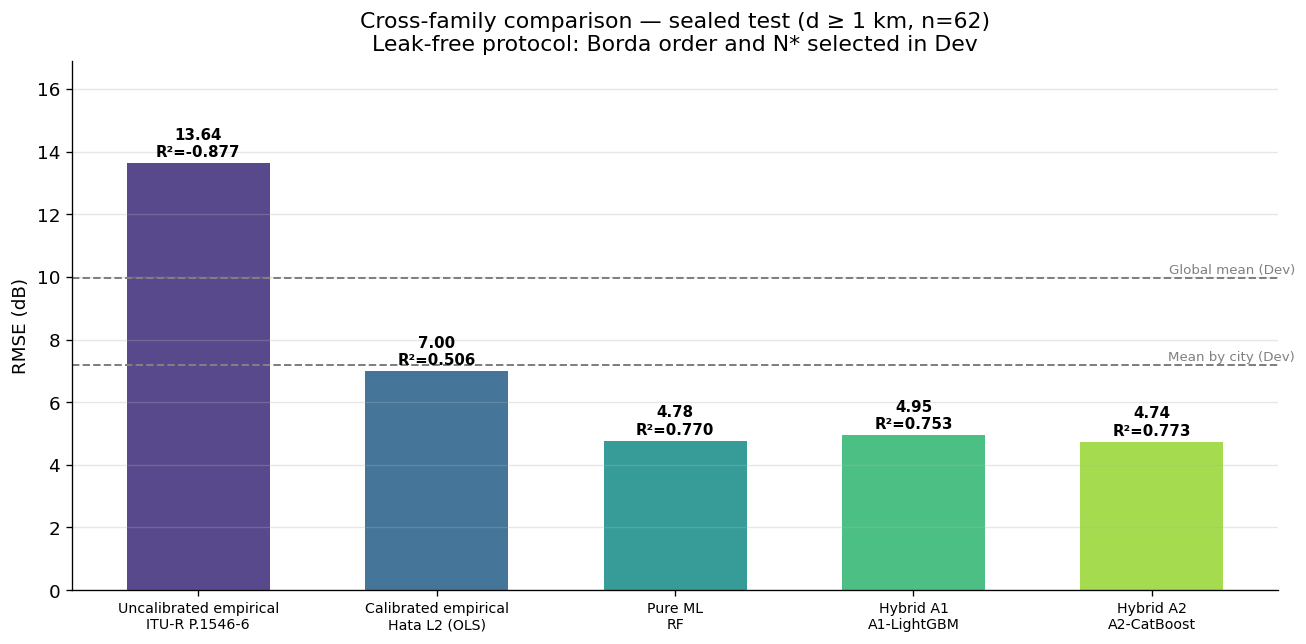

In [12]:
# ── Tableau de synthèse : meilleur de chaque famille ────────────────────────
best = (full[full['Famille'] != 'Trivial baseline']
        .sort_values('RMSE').groupby('Famille', as_index=False).first())
order = ['Uncalibrated empirical', 'Calibrated empirical', 'Pure ML', 'Hybrid A1', 'Hybrid A2']
best['o'] = best['Famille'].map({f: i for i, f in enumerate(order)})
best = best.sort_values('o').drop(columns='o')
triv = full[full['Famille'] == 'Trivial baseline']
synth = pd.concat([best, triv], ignore_index=True)[
    ['Famille', 'Modèle', 'N', 'RMSE', 'MAE', 'R2', 'Bias', 'R2_Urbain', 'R2_Suburbain']]
synth.to_csv(OUT / 'synthese_finale.csv', index=False)

print('=== SYNTHÈSE — meilleur représentant de chaque famille ===')
print(synth.to_string(index=False))

# ── Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5))
s = synth[synth['Famille'] != 'Trivial baseline']
cols = plt.cm.viridis(np.linspace(0.15, 0.85, len(s)))
b = ax.bar(range(len(s)), s['RMSE'], color=cols, alpha=0.9, width=0.6)
for bar, (_, r) in zip(b, s.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f"{r['RMSE']:.2f}\nR²={r['R2']:.3f}", ha='center', fontsize=9, fontweight='bold')
for _, r in triv.iterrows():
    ax.axhline(r['RMSE'], ls='--', lw=1.2, color='gray')
    ax.text(len(s)-0.4, r['RMSE']+0.15, r['Modèle'], fontsize=8, color='gray', ha='right')
ax.set_xticks(range(len(s)))
ax.set_xticklabels([f"{r['Famille']}\n{r['Modèle']}" for _, r in s.iterrows()], fontsize=8.5)
ax.set_ylabel('RMSE (dB)')
ax.set_title(f'Cross-family comparison — sealed test (d ≥ 1 km, n={len(test_f)})\n'
             'Leak-free protocol: Borda order and N* selected in Dev')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, ax.get_ylim()[1]*1.18)
plt.tight_layout()
plt.savefig(OUT / 'fig_cross_family_final.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig_cross_family_final.png', dpi=150, bbox_inches='tight')
plt.show()

---
## §7 — Quantification de la fuite sur les hybrides

L'ancien protocole (ablation A1/A2 évaluée sur le test, N\* = `argmin`) est rejoué sur les mêmes données et le même split. L'écart isole l'effet du protocole.

In [13]:
rows_leak = []
for n in range(1, 20):
    feats = BORDA_ORDER[:n]
    r = {'N': n}
    for mdl in ML_NAMES:
        m1 = build_ml(mdl)
        m1.fit(np.column_stack([dev_f[feats].values, e_l2_dev]), y_dev_f)
        p1 = m1.predict(np.column_stack([test_f[feats].values, e_l2_test]))
        r[f'A1_{mdl}'] = float(np.sqrt(mean_squared_error(y_test_f, p1)))
        m2 = build_ml(mdl); m2.fit(dev_f[feats].values, delta_l2_dev)
        p2 = e_l2_test + m2.predict(test_f[feats].values)
        r[f'A2_{mdl}'] = float(np.sqrt(mean_squared_error(y_test_f, p2)))
    rows_leak.append(r)
leak = pd.DataFrame(rows_leak)
leak.to_csv(OUT / 'ablation_hybride_ancien_protocole.csv', index=False)

cmp_rows = []
for approche, ns in [('A1', NSTAR_A1), ('A2', NSTAR_A2)]:
    for mdl in ML_NAMES:
        col = f'{approche}_{mdl}'
        j   = int(leak[col].idxmin())
        rmse_propre = float(full[full['Modèle'] == f'{approche}-{mdl}']['RMSE'].iloc[0])
        cmp_rows.append({
            'Approche': approche, 'Model': mdl,
            'N*_ancien': int(leak.loc[j, 'N']), 'RMSE_ancien': round(leak.loc[j, col], 3),
            'N*_propre': ns[mdl], 'RMSE_propre': rmse_propre,
            'Biais_optimiste': round(rmse_propre - leak.loc[j, col], 3)})
cmp_hyb = pd.DataFrame(cmp_rows)
cmp_hyb.to_csv(OUT / 'comparaison_protocoles_hybrides.csv', index=False)

print('=== Hybrides : ancien protocole (sélection sur test) vs protocole propre ===')
print('Mêmes données, même split — seul le protocole change.\n')
print(cmp_hyb.to_string(index=False))
print()
print(f"Biais optimiste moyen : {cmp_hyb['Biais_optimiste'].mean():+.3f} dB")

=== Hybrides : ancien protocole (sélection sur test) vs protocole propre ===
Mêmes données, même split — seul le protocole change.

Approche    Model  N*_ancien  RMSE_ancien  N*_propre  RMSE_propre  Biais_optimiste
      A1       RF         15        4.773          3        5.190            0.417
      A1  XGBoost         16        4.678          4        5.002            0.324
      A1 CatBoost          7        4.587          3        5.277            0.690
      A1 LightGBM          7        4.749         13        4.952            0.203
      A2       RF         17        4.637          3        5.233            0.596
      A2  XGBoost         17        4.560          5        5.054            0.494
      A2 CatBoost         19        4.645          5        4.738            0.093
      A2 LightGBM          7        4.868          7        4.868            0.000

Biais optimiste moyen : +0.352 dB


---
## §8 — Ce qui reste

Le notebook 05 (augmentation) n'est pas repris : le notebook 06 avait déjà établi que le gain de CTGAN n'était pas reproductible une fois la graine fixée, et la ligne avait été retirée du tableau final. Si tu veux la rétablir, il faudra choisir `Size_opt` en validation dans Dev — même correction qu'ici — et rapporter le gain avec un intervalle de confiance.

Deux points relevés au passage, à traiter dans la rédaction plutôt que dans le code :

**La régression L2 n'est pas identifiable** (§3). Sa matrice de design est de rang déficient parce que `a_hm` est constante et que `log_f`, `log_erp` et `Environment` ne prennent que deux valeurs, toutes déterminées par la ville. Les prédictions Ê_L2 restent valides — c'est ce qui compte pour L2 comme pour les hybrides — mais les valeurs des coefficients ne le sont pas, et l'article les interprète comme des exposants de propagation ré-estimés. Deux options : ne rapporter que le RMSE de L2 sans commenter les coefficients, ou re-paramétrer le modèle sur les seules covariables identifiables (`log_d`, `log_hb_log_d`, `Environment`, constante).

**Le R² par environnement** est reporté dans le tableau du §6. C'est la ventilation qu'un relecteur demandera sur un jeu à deux villes.
